# Netflix Content Analysis EDA
## Objective : 
The objective of this project is to perform exploratory data analysis on Netflix's content catalog to identify patterns and trends related to movies, TV shows, content ratings, genres, countries of origin, and release years. The project aims to derive meaningful business insights that can help understand content distribution and growth trends on the platform using Python, Pandas, NumPy, Matplotlib, and Seaborn.

## Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Loading the data

In [2]:
df = pd.read_csv("../data/netflix_dataset.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Exploring the data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

In [5]:
df["listed_in"].head()

0                                        Documentaries
1      International TV Shows, TV Dramas, TV Mysteries
2    Crime TV Shows, International TV Shows, TV Act...
3                               Docuseries, Reality TV
4    International TV Shows, Romantic TV Shows, TV ...
Name: listed_in, dtype: object

In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## Cleaning the data

In [7]:
df["director"] = df["director"].fillna("unknown")
df["cast"] = df["cast"].fillna("unknown")
df["country"] = df["country"].fillna("unknown")
df["rating"] = df["rating"].fillna("unknown")
df["duration"] = df["duration"].fillna("unknown")
df.dropna(subset=["date_added"], inplace=True)
print("Fixed null values!")

Fixed null values!


## Q1 : How many movies and tv shows exist?

In [29]:
type_count = df["type"].value_counts()
type_count

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

#### Conclusion : The number of movies is significantly larger than the number of tv shows!

## Q2 : Which countries contribute the most content?

In [9]:
df["country"] = df["country"].apply(lambda x : x.split(','))
df["country"] = df["country"].apply(lambda x : [country.strip() for country in x])
df["country"].head()

0    [United States]
1     [South Africa]
2          [unknown]
3          [unknown]
4            [India]
Name: country, dtype: object

In [10]:
country_df = df.explode("country")
country_df = country_df[country_df["country"] != "unknown"]
country_df[["show_id", "title", "country"]].head()

,show_id,title,country
0,s1,Dick Johnson Is Dead,United States
1,s2,Blood & Water,South Africa
4,s5,Kota Factory,India
7,s8,Sankofa,United States
7,s8,Sankofa,Ghana


In [11]:
country_count = country_df["country"].value_counts()
country_count.head()

country
United States     3684
India             1046
United Kingdom     805
Canada             445
France             393
Name: count, dtype: int64

#### Conclusion : Top 3 countries contributing the most are ->| 1. US | 2. India | 3. UK |

## Q3 : What are the most common content ratings?

In [12]:
rating_count = df["rating"].value_counts()
rating_count.head()

rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
Name: count, dtype: int64

### Conclusion : The top 3 ratings are -> | 1. TV-MA | 2. TV-14 | 3. TV-PG | 
### means most of the content are for adults

## Q4 : Which year produced the most content?

In [13]:
release_year_count = df["release_year"].value_counts()
release_year_count.head()

release_year
2018    1146
2017    1032
2019    1030
2020     953
2016     901
Name: count, dtype: int64

#### Conclusion : Most of the content was produced in 2018!

## Q5: Has Netflix's catalog grown over time?

In [14]:
df["date_added"] = df["date_added"].str.strip()
df["date_added"] = pd.to_datetime(df["date_added"])

In [15]:
df["year_added"] = df["date_added"].dt.year

In [16]:
year_added_count = df["year_added"].value_counts().sort_index()
year_added_count.head()

year_added
2008     2
2009     2
2010     1
2011    13
2012     3
Name: count, dtype: int64

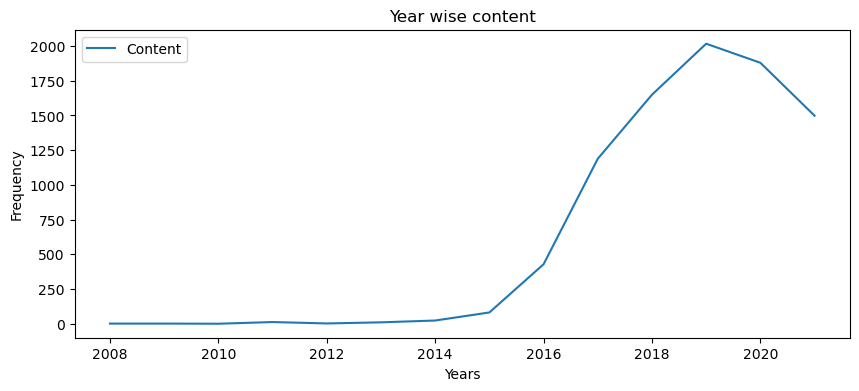

In [17]:
plt.figure(figsize=(10, 4))
plt.plot(year_added_count.index, year_added_count.values, label="Content")
plt.legend()
plt.xlabel("Years")
plt.ylabel("Frequency")
plt.title("Year wise content")
plt.show()

#### Conclusion : Yes, netflix's catalog has increased over time but became less in quantity after 2020!

## Q6 : Has released content increased over time?

In [18]:
yearly_released_content_count = df["release_year"].value_counts().sort_index()
yearly_released_content_count.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    4
Name: count, dtype: int64

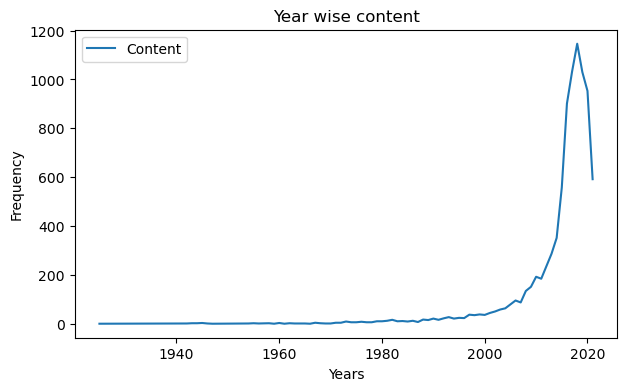

In [19]:
plt.figure(figsize=(7, 4))
plt.plot(yearly_released_content_count.index, yearly_released_content_count.values, label="Content")
plt.legend()
plt.xlabel("Years")
plt.ylabel("Frequency")
plt.title("Year wise content")
plt.show()

#### Conclusion : Yes, released content has increased over time and went to peak around 2020 (Covid era), but after that it started decreasing!

## Q7 : Are movies and tv shows growing at the same rate?

In [20]:
yearly_content = df.groupby(["release_year", "type"])["type"].count()
yearly_content = yearly_content.unstack()
yearly_content.head()

type,Movie,TV Show
release_year,,
1925,NaN,1.0
1942,2.0,NaN
1943,3.0,NaN
1944,3.0,NaN
1945,3.0,1.0


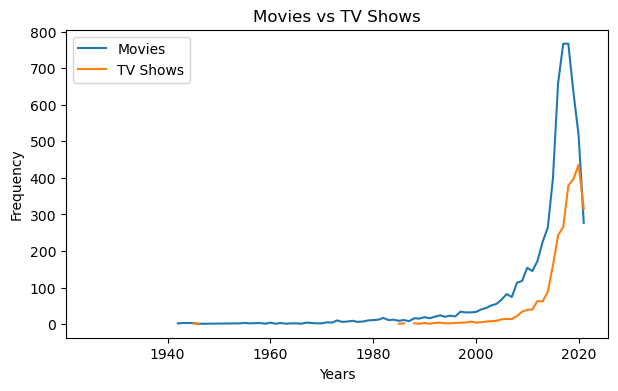

In [21]:
plt.figure(figsize=(7, 4))
plt.plot(yearly_content.index, yearly_content["Movie"], label="Movies")
plt.plot(yearly_content.index, yearly_content["TV Show"], label="TV Shows")
plt.legend()
plt.title("Movies vs TV Shows")
plt.xlabel("Years")
plt.ylabel("Frequency")
plt.show()

#### Conclusion : No, movies were dominant from the start and went to peak around 2020 while TV Shows tried to keep up, in late 2020, both type content became low in frequency, especially Movies!

## Q8 : What genre appears more frequently?

In [22]:
df["listed_in"] = df["listed_in"].apply(lambda x : x.split(','))
df["listed_in"] = df["listed_in"].apply(lambda x : [genre.strip() for genre in x])

In [23]:
genre_df = df.explode("listed_in")
genre_df[["show_id", "title", "listed_in"]].head()

,show_id,title,listed_in
0,s1,Dick Johnson Is Dead,Documentaries
1,s2,Blood & Water,International TV Shows
1,s2,Blood & Water,TV Dramas
1,s2,Blood & Water,TV Mysteries
2,s3,Ganglands,Crime TV Shows


In [24]:
genre_count = genre_df["listed_in"].value_counts()
genre_count.head()

listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1350
Documentaries              869
Name: count, dtype: int64

#### Conclusion : Top 3 genres appearing most frequently are -> | 1. International Movies | 2. Dramas | 3. Comedies | !

## Q9 : Does netflix offers more documentaries or dramas?

In [25]:
# genre_count - used earlier
genre_count[["Documentaries", "Dramas"]]

listed_in
Documentaries     869
Dramas           2427
Name: count, dtype: int64

#### Conclusion : Netflix offers more drama content!

## Visualizations

### 1. Top Countries

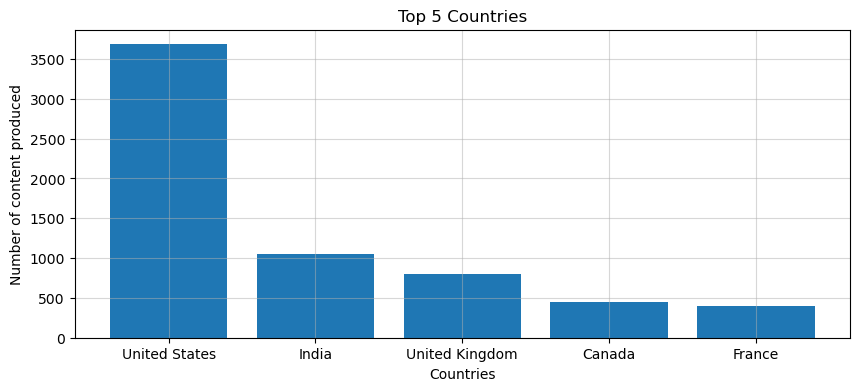

In [26]:
# country_count - used earlier
plt.figure(figsize=(10, 4))
plt.bar(country_count.index[:5], country_count.values[:5])
plt.grid(True, alpha=0.5)
plt.xlabel("Countries")
plt.ylabel("Number of content produced")
plt.title("Top 5 Countries")
plt.show()

### 2. Top Genres

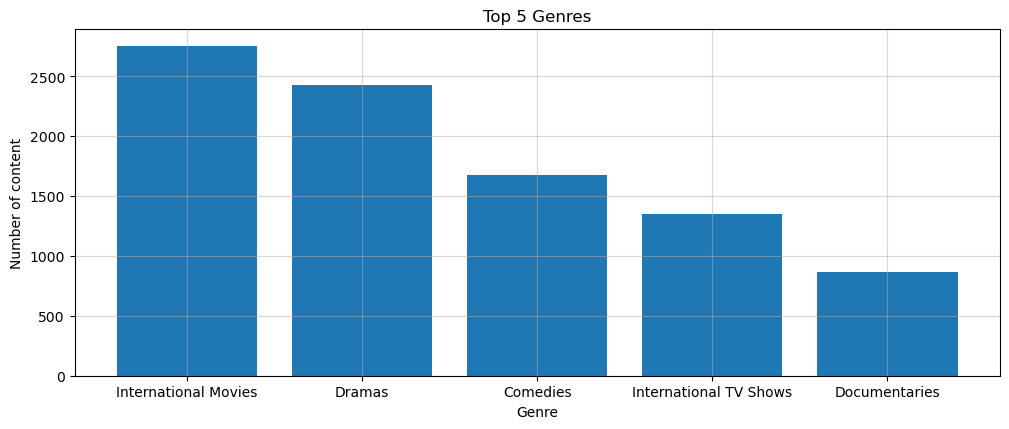

In [27]:
# genre_count - used earlier
plt.figure(figsize=(10, 4))
plt.bar(genre_count.index[:5], genre_count.values[:5])
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.xlabel("Genre")
plt.ylabel("Number of content")
plt.title("Top 5 Genres")
plt.show()

### 3. Rating Distribution

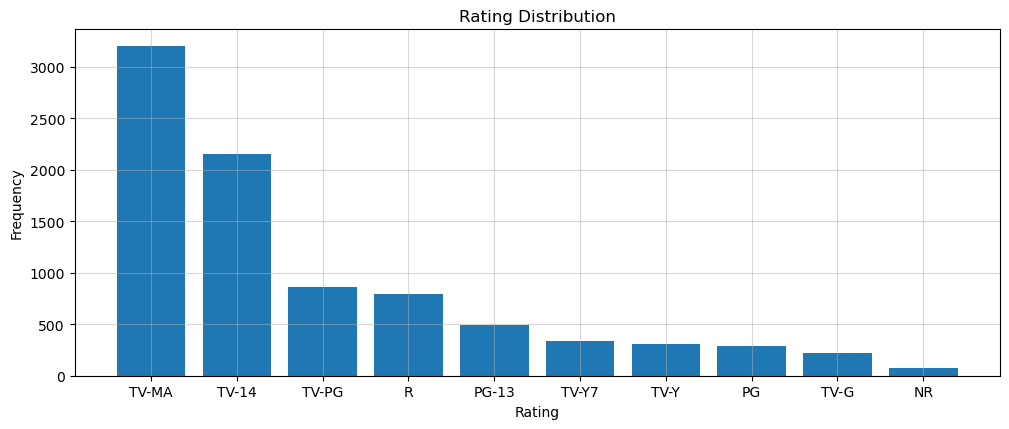

In [28]:
# rating_count - used earlier
plt.figure(figsize=(10, 4))
plt.bar(rating_count.index[:10], rating_count.values[:10])
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.title("Rating Distribution")
plt.show()